# PM2.5 Walk-Forward Validation — Gradient Boosting
## Daily-Level Testing | Skip Heating Season in First Year
### Train[1..N months] → Test[month N+1 daily data]
### First Year: Train on heating months, don't predict | After: Predict with full data
### AQI lags + EWM7 + EWM14 | MAE · RMSE · MAPE · R²

## 1. Imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import warnings
warnings.filterwarnings('ignore')
import requests

from sklearn.metrics import (mean_squared_error, mean_absolute_error,
                              r2_score, mean_absolute_percentage_error)

print('Ready Gradient Boosting with Heating Season Validation')

Ready Gradient Boosting with Heating Season Validation


## 2. Load Data

In [2]:
df = pd.read_csv('sensor_14_aqi.csv', parse_dates=['date'])
df.rename(columns={'aqi': 'y', 'date': 'ds'}, inplace=True)
df = df.sort_values('ds').reset_index(drop=True)
df['y'] = pd.to_numeric(df['y'], errors='coerce')
df.dropna(subset=['y'], inplace=True)
df.reset_index(drop=True, inplace=True)
print(f'Shape: {df.shape}  |  {df["ds"].min().date()} -> {df["ds"].max().date()}')

Shape: (1030, 2)  |  2017-07-20 -> 2020-05-14


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1030 entries, 0 to 1029
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype         
---  ------  --------------  -----         
 0   ds      1030 non-null   datetime64[ns]
 1   y       1030 non-null   float64       
dtypes: datetime64[ns](1), float64(1)
memory usage: 16.2 KB


## 3. Feature Engineering (Daily Level)

In [4]:
def build_features(df):
    d = df[['ds', 'y']].copy()

    # ── Lag features (short + medium-range) ──────────────────────────────
    for lag in [1, 2, 3, 7, 14, 21, 28]:
        d[f'lag_{lag}'] = d['y'].shift(lag)

    y_past = d['y'].shift(1)

    # ── Exponentially-weighted means ─────────────────────────────────────
    d['ewm_3']  = y_past.ewm(span=3).mean()
    d['ewm_7']  = y_past.ewm(span=7).mean()
    d['ewm_14'] = y_past.ewm(span=14).mean()

    # ── Rolling statistics (level + volatility) ──────────────────────────
    d['rolling_7']     = y_past.rolling(7).mean()
    d['rolling_14']    = y_past.rolling(14).mean()
    d['rolling_std_7'] = y_past.rolling(7).std()   # volatility — helps MAPE on spikes
    d['rolling_std_14']= y_past.rolling(14).std()

    # ── Calendar features ────────────────────────────────────────────────
    d['month']      = d['ds'].dt.month
    d['dayofweek']  = d['ds'].dt.dayofweek
    d['dayofyear']  = d['ds'].dt.dayofyear
    d['year_month'] = d['ds'].dt.to_period('M').astype(str)

    # ── Domain knowledge: heating season flag ────────────────────────────
    #    PM2.5 behaves very differently in heating vs non-heating months
    HEATING_MONTHS = {11, 12, 1, 2, 3}
    d['is_heating'] = d['month'].isin(HEATING_MONTHS).astype(int)

    return d.dropna().reset_index(drop=True)

feat_df = build_features(df)
print(f'Features built (daily): {feat_df.shape}')
print(f'Date range: {feat_df["ds"].min().date()} -> {feat_df["ds"].max().date()}')

Features built (daily): (1002, 21)
Date range: 2017-08-17 -> 2020-05-14


In [5]:
feat_df.isna().sum()

ds                0
y                 0
lag_1             0
lag_2             0
lag_3             0
lag_7             0
lag_14            0
lag_21            0
lag_28            0
ewm_3             0
ewm_7             0
ewm_14            0
rolling_7         0
rolling_14        0
rolling_std_7     0
rolling_std_14    0
month             0
dayofweek         0
dayofyear         0
year_month        0
is_heating        0
dtype: int64

## 4. Metrics Helper

In [6]:
def get_metrics(y_true, y_pred, name=''):
    yt = np.array(y_true, dtype=float)
    yp = np.array(y_pred, dtype=float)
    mae = mean_absolute_error(yt, yp)
    rmse = np.sqrt(mean_squared_error(yt, yp))
    r2 = r2_score(yt, yp)
    mape = mean_absolute_percentage_error(yt, yp) * 100
    if name:
        print(f'{name:30s}  MAE={mae:6.2f}  RMSE={rmse:6.2f}  MAPE={mape:6.1f}%  R²={r2:7.4f}')
    return {'MAE': mae, 'RMSE': rmse, 'MAPE(%)': mape, 'R2': r2}

print('Metrics function ready')

Metrics function ready


In [7]:
feat_df.columns


Index(['ds', 'y', 'lag_1', 'lag_2', 'lag_3', 'lag_7', 'lag_14', 'lag_21',
       'lag_28', 'ewm_3', 'ewm_7', 'ewm_14', 'rolling_7', 'rolling_14',
       'rolling_std_7', 'rolling_std_14', 'month', 'dayofweek', 'dayofyear',
       'year_month', 'is_heating'],
      dtype='object')

## 5. Define Feature Columns

In [8]:
FEATURE_COLS = [
    'lag_1', 'lag_2', 'lag_3', 'lag_7', 'lag_14', 'lag_21', 'lag_28',
    'ewm_3', 'ewm_7', 'ewm_14',
    'rolling_7', 'rolling_14', 'rolling_std_7', 'rolling_std_14',
    'month', 'dayofweek', 'dayofyear', 'is_heating',
]
print(f'Features: {len(FEATURE_COLS)} columns')
print(f'  {FEATURE_COLS}')

Features: 18 columns
  ['lag_1', 'lag_2', 'lag_3', 'lag_7', 'lag_14', 'lag_21', 'lag_28', 'ewm_3', 'ewm_7', 'ewm_14', 'rolling_7', 'rolling_14', 'rolling_std_7', 'rolling_std_14', 'month', 'dayofweek', 'dayofyear', 'is_heating']


## 6. Fold Setup with Heating Season Validation

In [9]:
HEATING_MONTHS = {11, 12, 1, 2, 3}  # Nov, Dec, Jan, Feb, Mar

def is_heating_month(year_month_str):
    return int(year_month_str.split('-')[1]) in HEATING_MONTHS

def has_heating_in_training(train_months_list):
    return any(is_heating_month(m) for m in train_months_list)

def get_year_from_month(year_month_str):
    return int(year_month_str.split('-')[0])

all_months = sorted(feat_df['year_month'].unique())
first_year = get_year_from_month(all_months[0])

first_heating_end_idx = None
entered_heating = False
for idx, m in enumerate(all_months):
    if is_heating_month(m):
        entered_heating = True
    elif entered_heating:
        first_heating_end_idx = idx  # First non-heating month after the first season
        break

print(f'First year: {first_year}')
if first_heating_end_idx:
    print(f'First heating season covers: {all_months[0]} -> {all_months[first_heating_end_idx - 1]}')
    print(f'Predictions start from: {all_months[first_heating_end_idx]}')


MIN_TRAIN_MONTHS = 2

folds        = []
skipped_info = []

for i in range(MIN_TRAIN_MONTHS, len(all_months)):
    train_months      = list(all_months[:i])
    test_month        = all_months[i]
    test_is_heating   = is_heating_month(test_month)
    train_has_heating = has_heating_in_training(train_months)

    #entire first heating season (Nov/Dec year1 + Jan/Feb/Mar year2)
    if test_is_heating and first_heating_end_idx is not None and i < first_heating_end_idx:
        skipped_info.append({
            'test_month': test_month,
            'reason': 'Part of first heating season — used for training only'
        })
        continue

    # After first season: still require heating data in training before predicting heating months
    if test_is_heating and not train_has_heating:
        skipped_info.append({
            'test_month': test_month,
            'reason': 'No heating data in training yet'
        })
        continue

    folds.append({
        'train':              train_months,
        'test':               test_month,
        'test_is_heating':    test_is_heating,
        'train_has_heating':  train_has_heating,
        'train_months_count': len(train_months),
        'test_year':          get_year_from_month(test_month),
    })


print(f'\nTotal months: {len(all_months)}    {all_months[0]} → {all_months[-1]}')
print(f'Folds to predict:  {len(folds)}')
print(f'Months skipped:    {len(skipped_info)}')
if skipped_info:
    for skip in skipped_info:
        print(f'    {skip["test_month"]}: {skip["reason"]}')

print(f'\n{"Fold":<6} {"Test":<12} {"Year":<6} {"Train Span":<26} {"Type":<12} {"Status":<10}')
print(f'\n')
for j, fold in enumerate(folds):
    heating_mark = 'Heating'  if fold['test_is_heating'] else 'Non-Heat'
    train_span   = f"{fold['train'][0]}→{fold['train'][-1]}"
    print(f'{j+1:<6} {fold["test"]:<12} {fold["test_year"]:<6} {train_span:<26} {heating_mark:<12} PREDICT')


First year: 2017
First heating season covers: 2017-08 -> 2018-03
Predictions start from: 2018-04

Total months: 34    2017-08 → 2020-05
Folds to predict:  27
Months skipped:    5
    2017-11: Part of first heating season — used for training only
    2017-12: Part of first heating season — used for training only
    2018-01: Part of first heating season — used for training only
    2018-02: Part of first heating season — used for training only
    2018-03: Part of first heating season — used for training only

Fold   Test         Year   Train Span                 Type         Status    


1      2017-10      2017   2017-08→2017-09            Non-Heat     PREDICT
2      2018-04      2018   2017-08→2018-03            Non-Heat     PREDICT
3      2018-05      2018   2017-08→2018-04            Non-Heat     PREDICT
4      2018-06      2018   2017-08→2018-05            Non-Heat     PREDICT
5      2018-07      2018   2017-08→2018-06            Non-Heat     PREDICT
6      2018-08      2018   201

## 7. Hyperparameters & Walk-Forward Training

In [10]:
from sklearn.ensemble import HistGradientBoostingRegressor

# Poisson loss minimises a relative-error objective (gradient ∝ 1 - y/ŷ),
# which is the closest built-in loss to MAPE. It requires y > 0.
HGB_PARAMS = dict(
    loss              = 'poisson',   # relative-error loss → lower MAPE
    learning_rate     = 0.04,        # slightly lower → less overfit
    max_iter          = 600,         # more trees compensate lower LR
    max_depth         = 5,
    min_samples_leaf  = 4,
    l2_regularization = 0.05,
    max_bins          = 255,
    random_state      = 42,
)

MODEL_NAME  = 'HistGradientBoosting (Poisson)'
MODEL_COLOR = '#9B59B6'

fold_results = []
fold_preds   = []
lgb_imps     = []

print(f'  WALK-FORWARD: {MODEL_NAME} (Daily-level testing)')
print(f'  Loss: Poisson (relative-error objective — minimises MAPE)')
print()

for i, fold in enumerate(folds):
    test_month = fold['test']

    tr = feat_df[feat_df['year_month'].isin(fold['train'])].copy()
    te = feat_df[feat_df['year_month'] == test_month].copy()

    if len(te) < 3:
        print(f'  Fold {i+1}: Test month {test_month} has {len(te)} samples, skipping')
        continue

    X_tr = tr[FEATURE_COLS].values
    # Poisson requires strictly positive targets; clip to 0.1 to avoid
    # near-zero blowup (also stabilises MAPE on the test side)
    y_tr = np.clip(tr['y'].values, 0.1, None)
    X_te, y_te = te[FEATURE_COLS].values, te['y'].values

    model = HistGradientBoostingRegressor(**HGB_PARAMS)
    model.fit(X_tr, y_tr)

    pred = np.clip(model.predict(X_te), 0.1, None)  # keep predictions positive
    m = get_metrics(y_te, pred, f'Fold {i+1:2d} ({test_month})  Train: {fold["train"][0]}→{fold["train"][-1]} ({len(fold["train"])}m, {len(tr):4d}d)  Test: {len(te):2d}d')

    # HistGBR exposes feature_importances_ (split-gain based) in sklearn ≥ 1.2
    if hasattr(model, 'feature_importances_'):
        lgb_imps.append(pd.Series(model.feature_importances_, index=FEATURE_COLS))

    fold_results.append({
        'fold': i+1,
        'test_month': str(test_month),
        'n_train_days': len(tr),
        'n_test_days': len(te),
        'is_heating_test': fold['test_is_heating'],
        'has_heating_in_train': fold['train_has_heating'],
        **m
    })

    fold_preds.append({
        'fold': i+1,
        'test_month': str(test_month),
        'is_heating_test': fold['test_is_heating'],
        'dates': te['ds'].values,
        'y_true': y_te,
        'pred': pred,
        'tr_dates': tr['ds'].values,
        'y_train': y_tr
    })

print(f'\nTraining complete! {len(fold_results)} folds trained.')

  WALK-FORWARD: HistGradientBoosting (Poisson) (Daily-level testing)
  Loss: Poisson (relative-error objective — minimises MAPE)

Fold  1 (2017-10)  Train: 2017-08→2017-09 (2m,   45d)  Test: 31d  MAE= 32.90  RMSE= 45.16  MAPE=  48.4%  R²=-1.1497
Fold  2 (2018-04)  Train: 2017-08→2018-03 (8m,  227d)  Test: 30d  MAE=  9.32  RMSE= 12.04  MAPE=  37.6%  R²=-0.0325
Fold  3 (2018-05)  Train: 2017-08→2018-04 (9m,  257d)  Test: 31d  MAE=  6.15  RMSE=  7.13  MAPE=  51.9%  R²=-0.3176
Fold  4 (2018-06)  Train: 2017-08→2018-05 (10m,  288d)  Test: 30d  MAE=  7.29  RMSE=  9.78  MAPE=  52.8%  R²=-0.3007
Fold  5 (2018-07)  Train: 2017-08→2018-06 (11m,  318d)  Test: 31d  MAE=  4.49  RMSE=  5.84  MAPE=  28.7%  R²=-0.1481
Fold  6 (2018-08)  Train: 2017-08→2018-07 (12m,  349d)  Test: 31d  MAE=  3.80  RMSE=  4.92  MAPE=  21.6%  R²= 0.2701
Fold  7 (2018-09)  Train: 2017-08→2018-08 (13m,  380d)  Test: 30d  MAE=  6.70  RMSE=  9.44  MAPE=  30.7%  R²= 0.0080
Fold  8 (2018-10)  Train: 2017-08→2018-09 (14m,  410d)

## 8. Per-Fold Plots

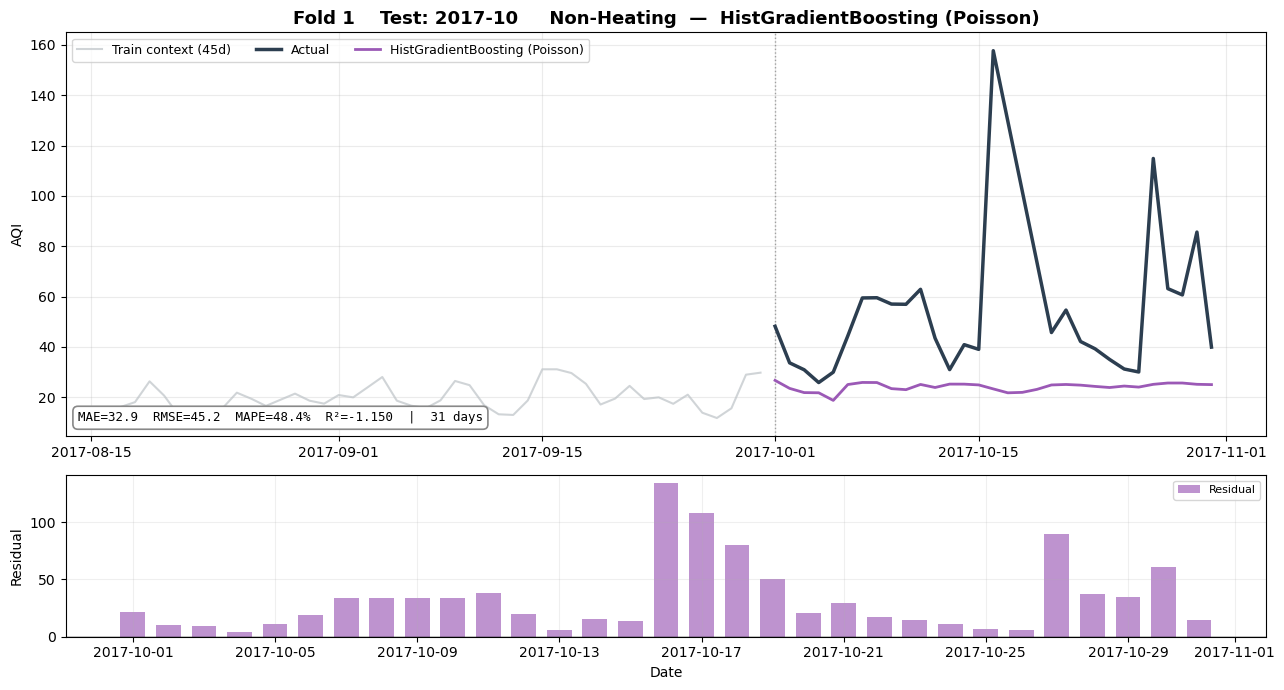

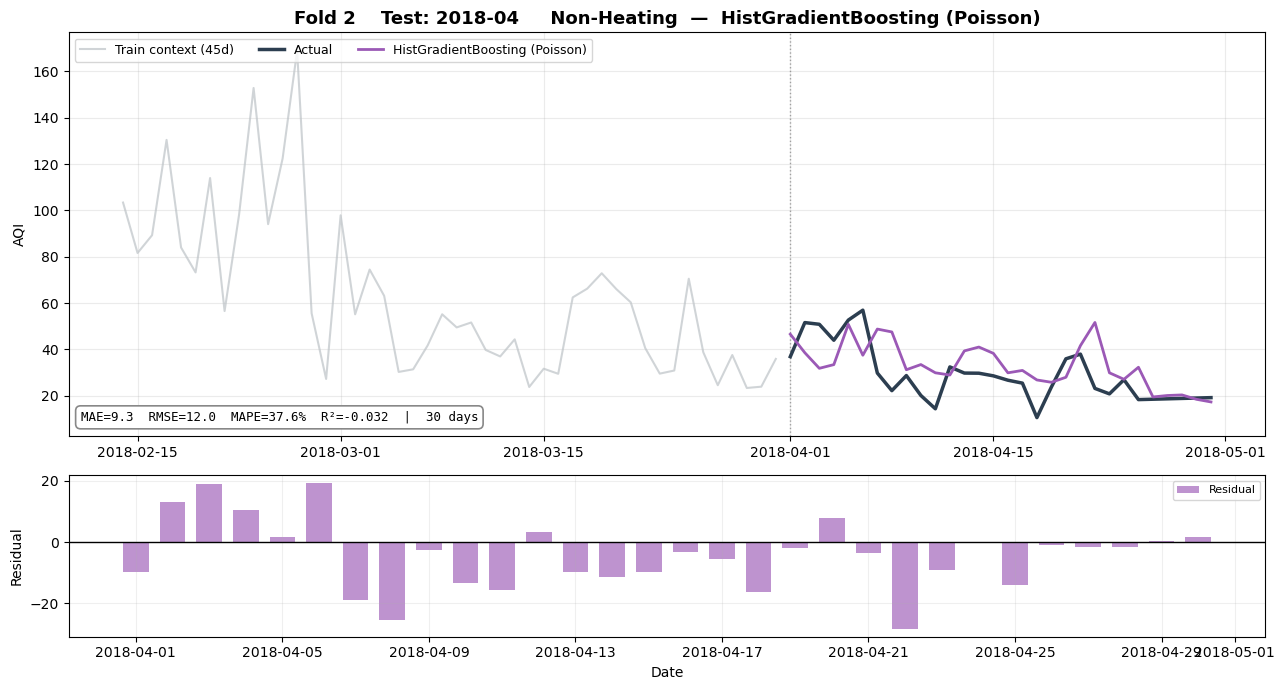

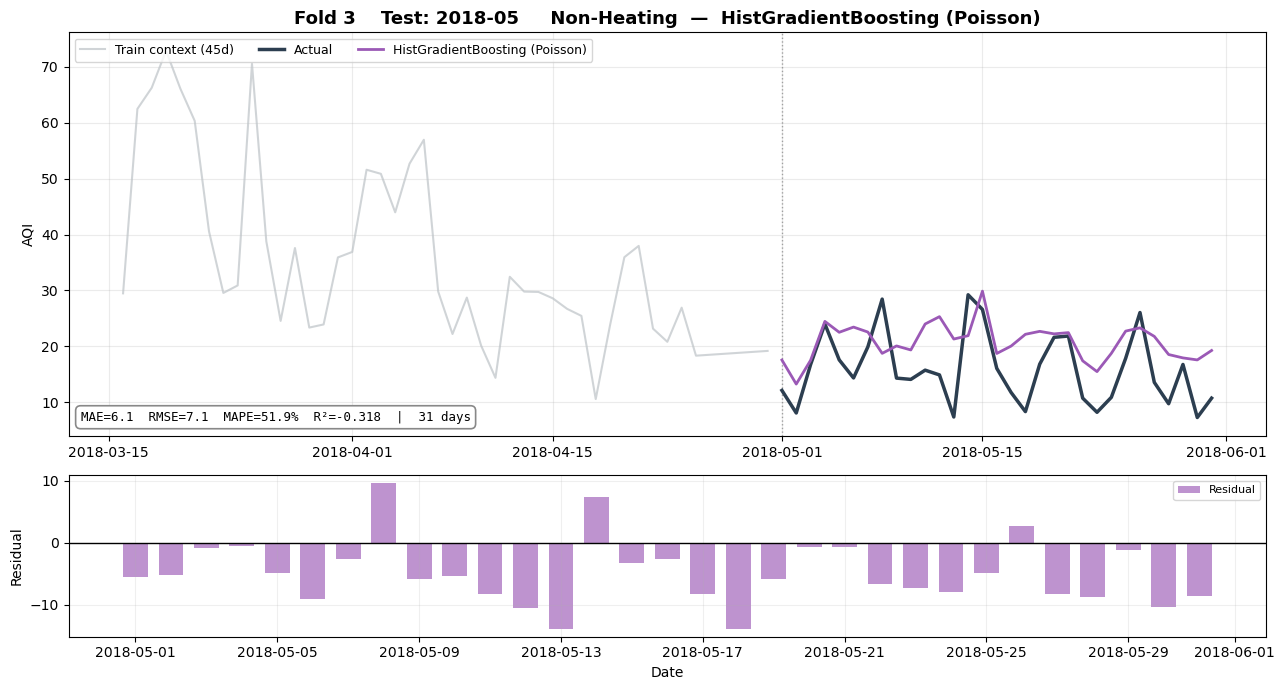

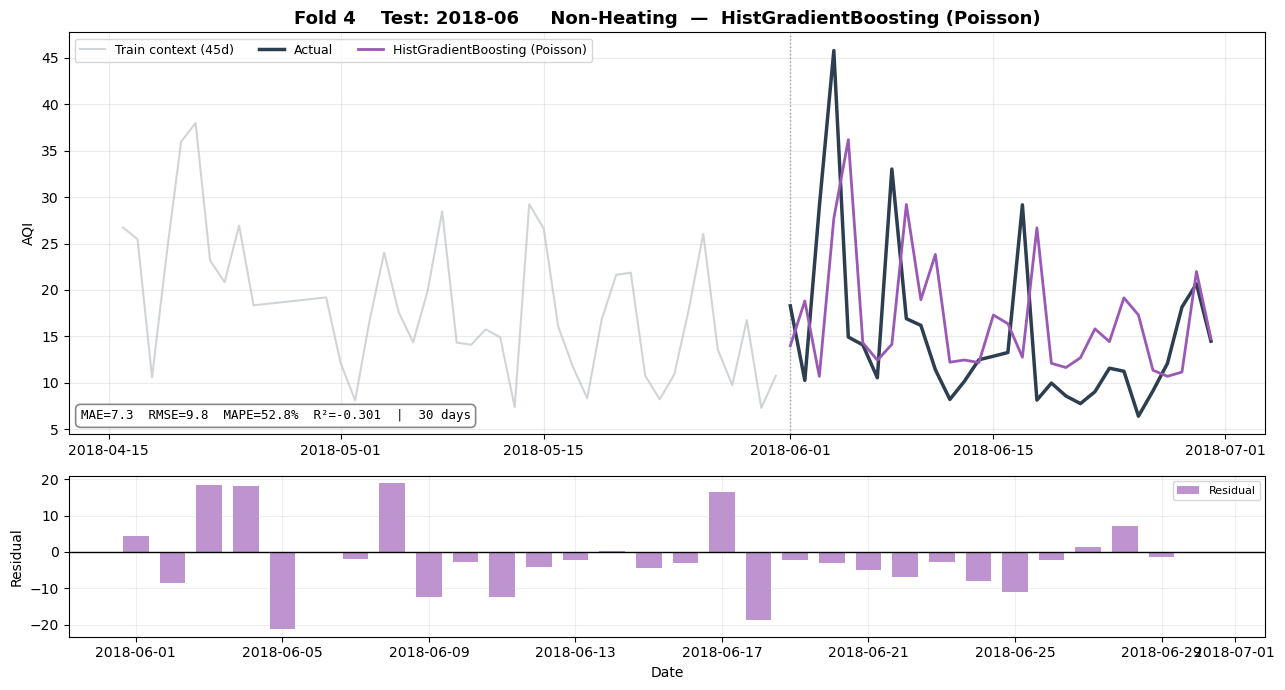

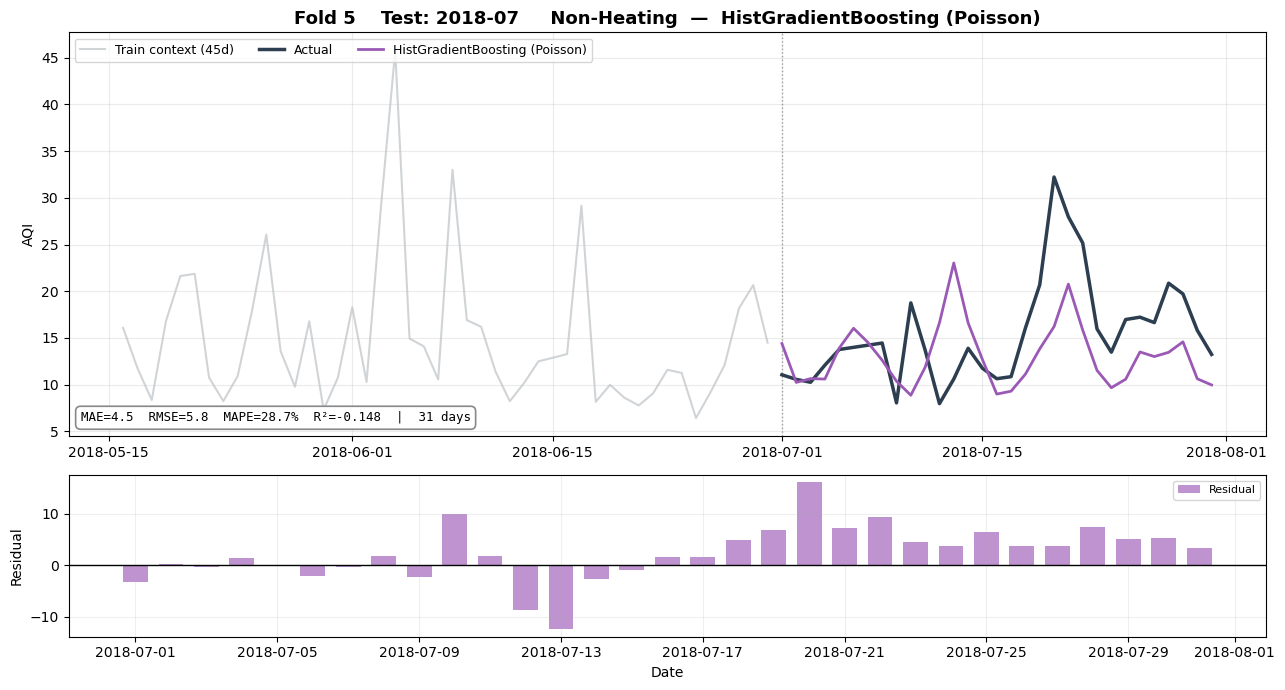

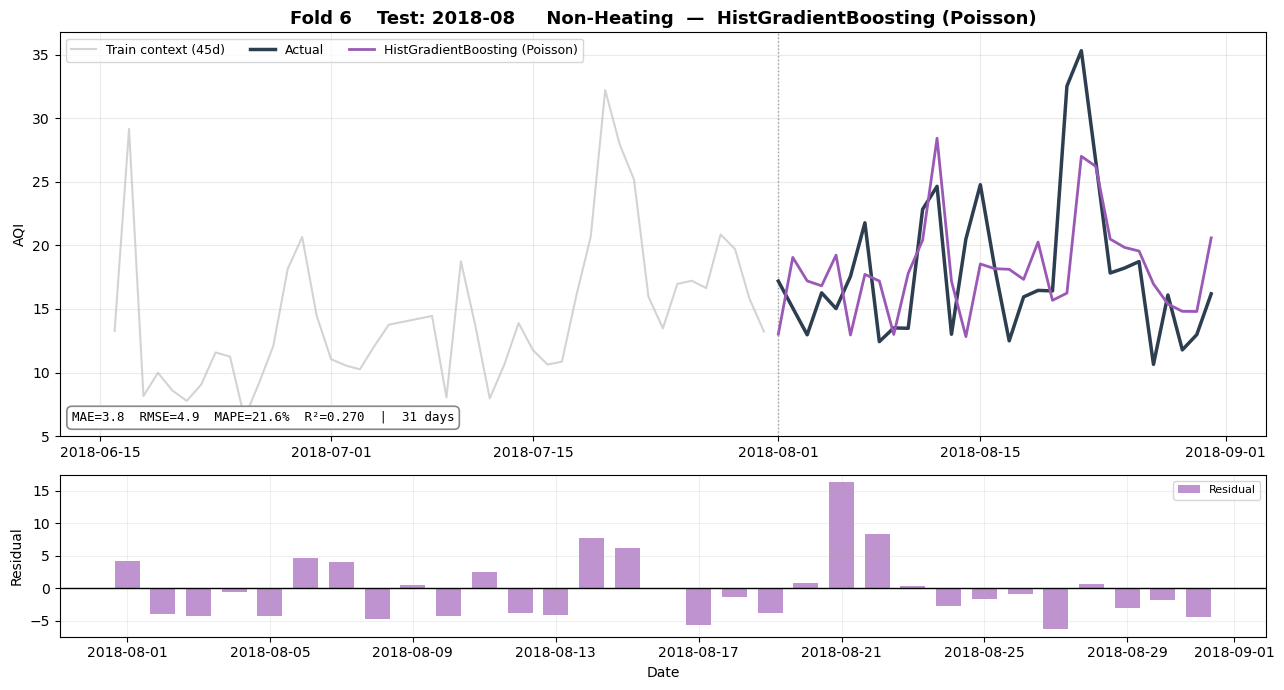

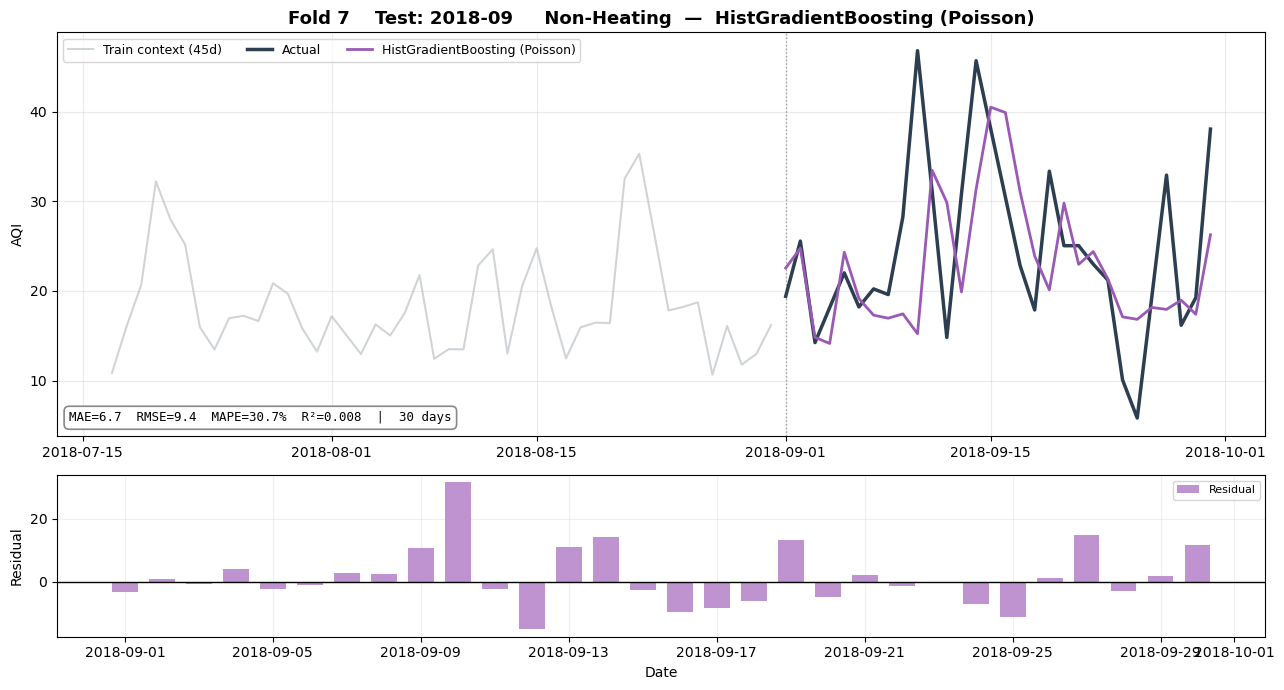

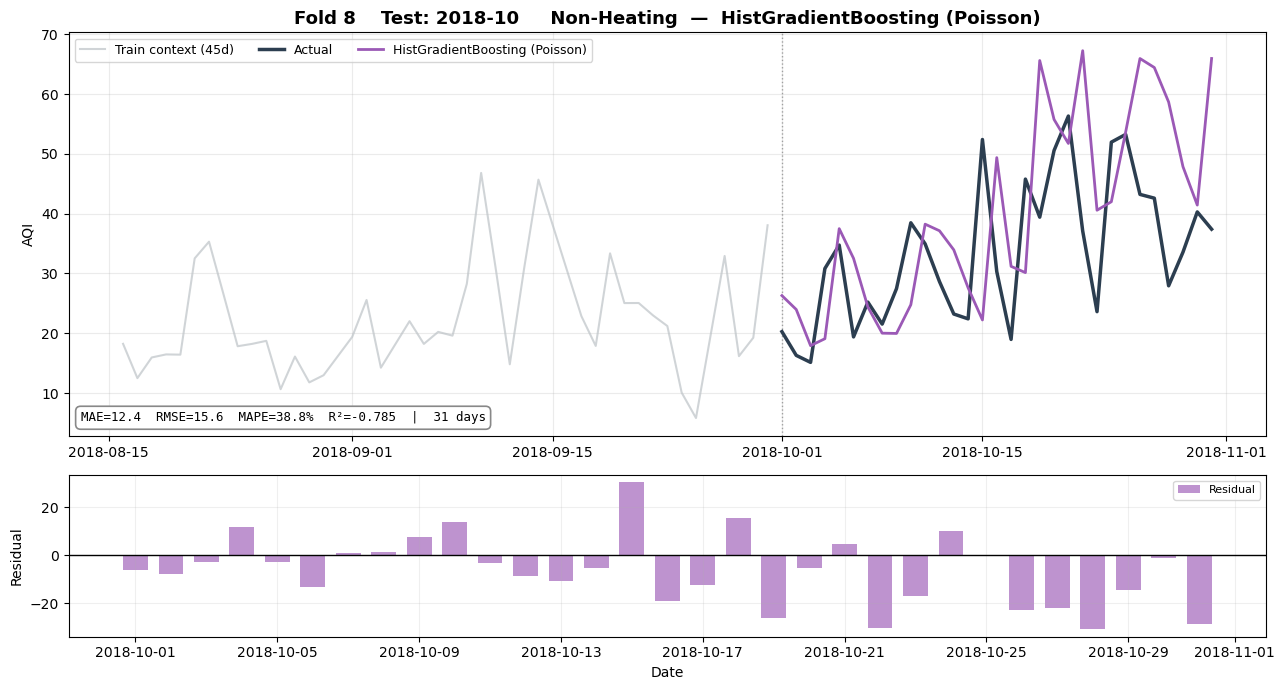

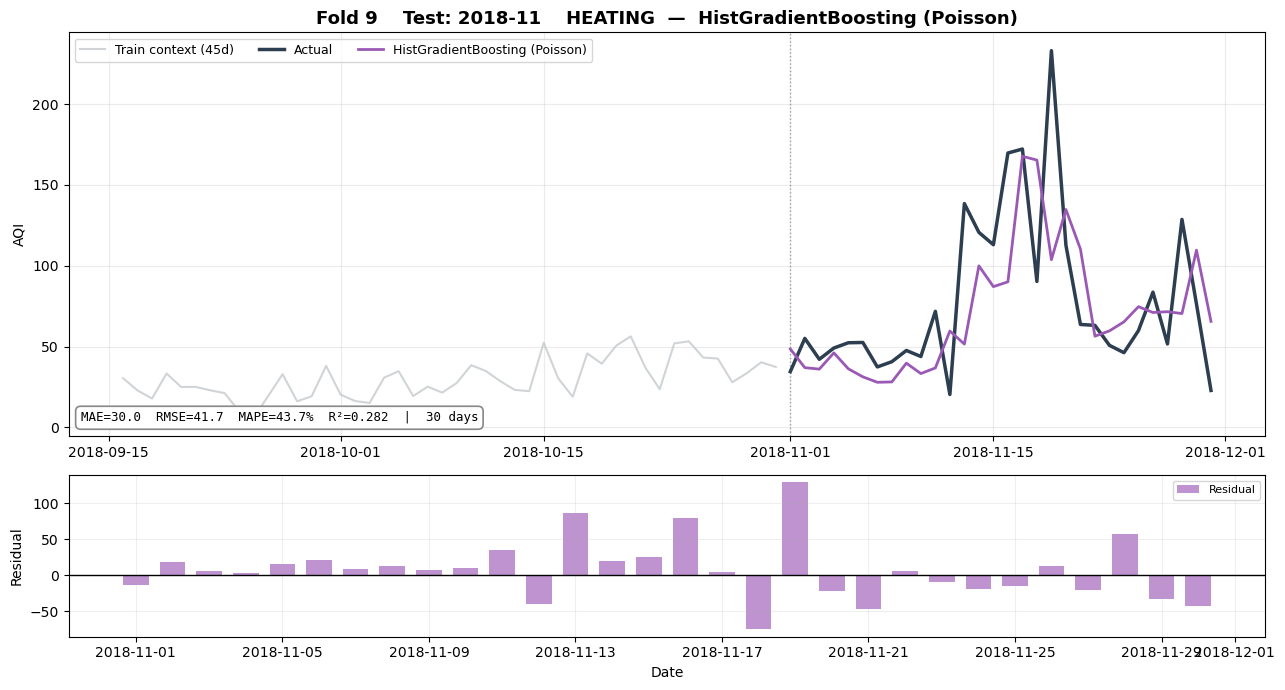

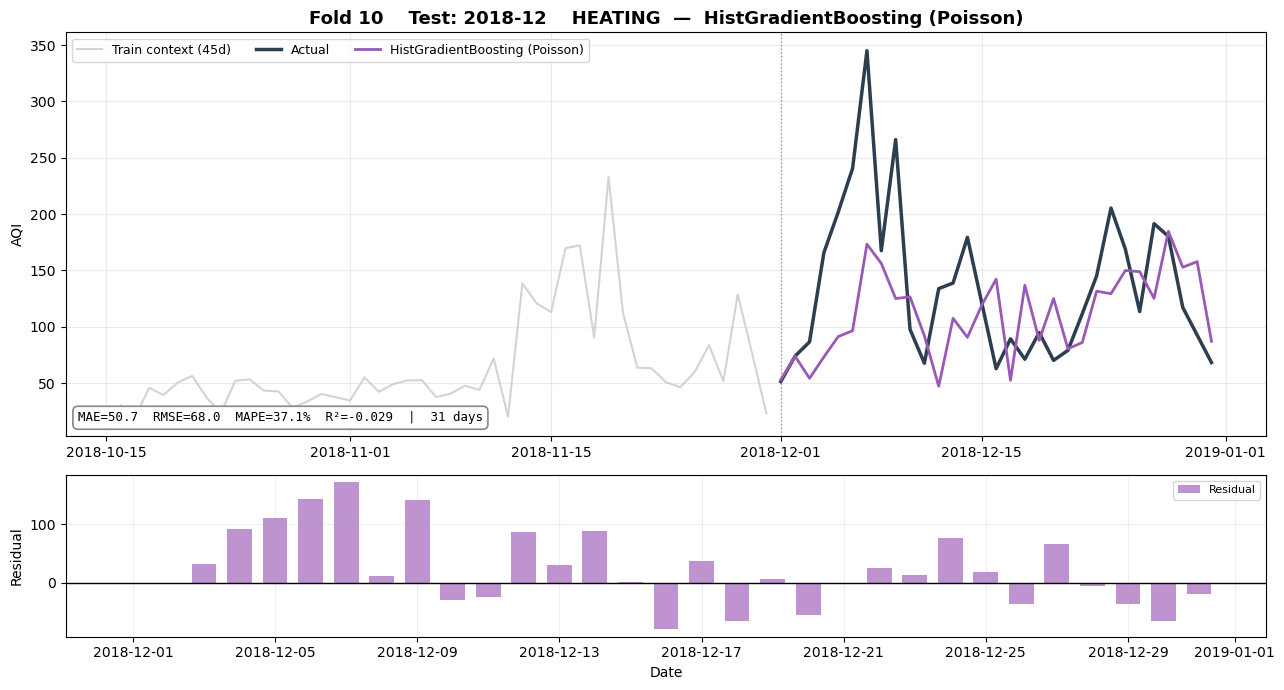

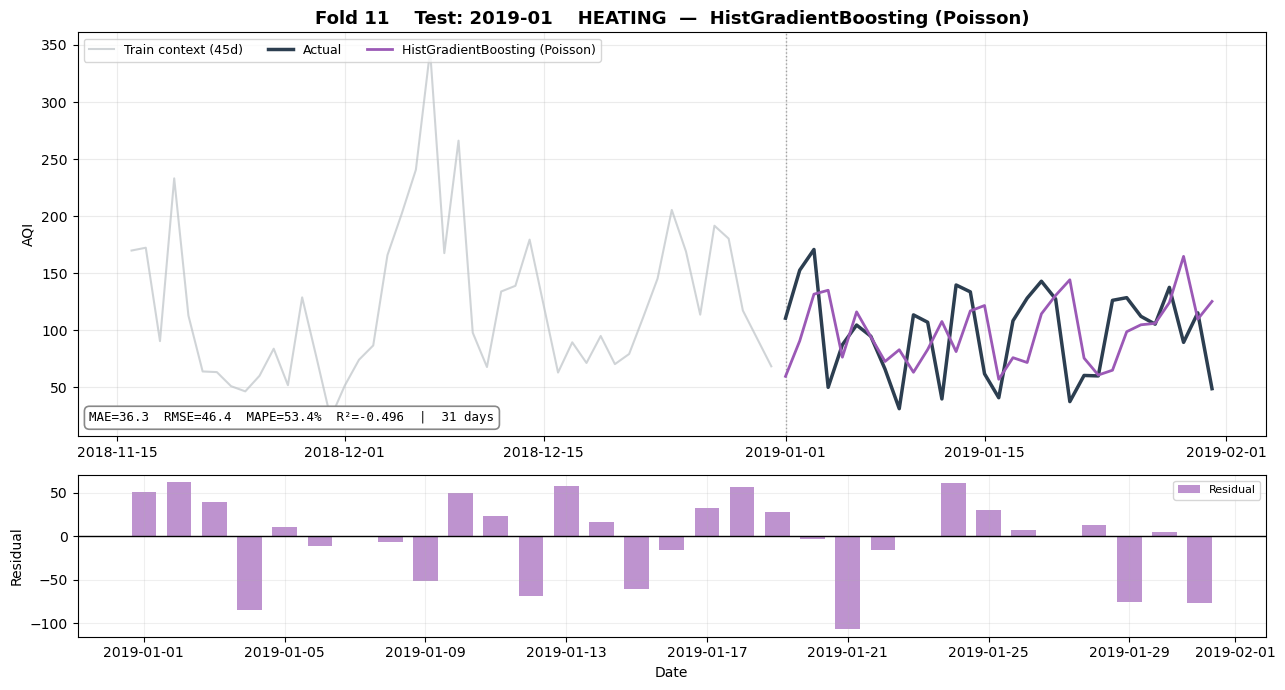

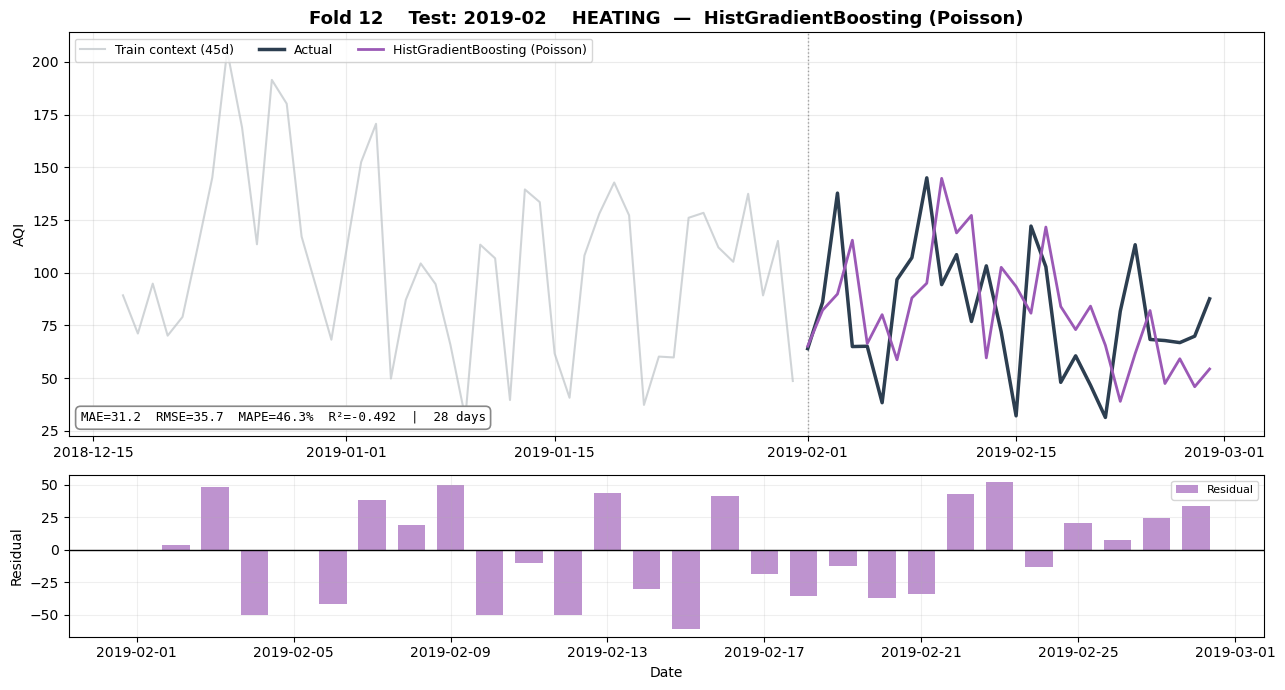

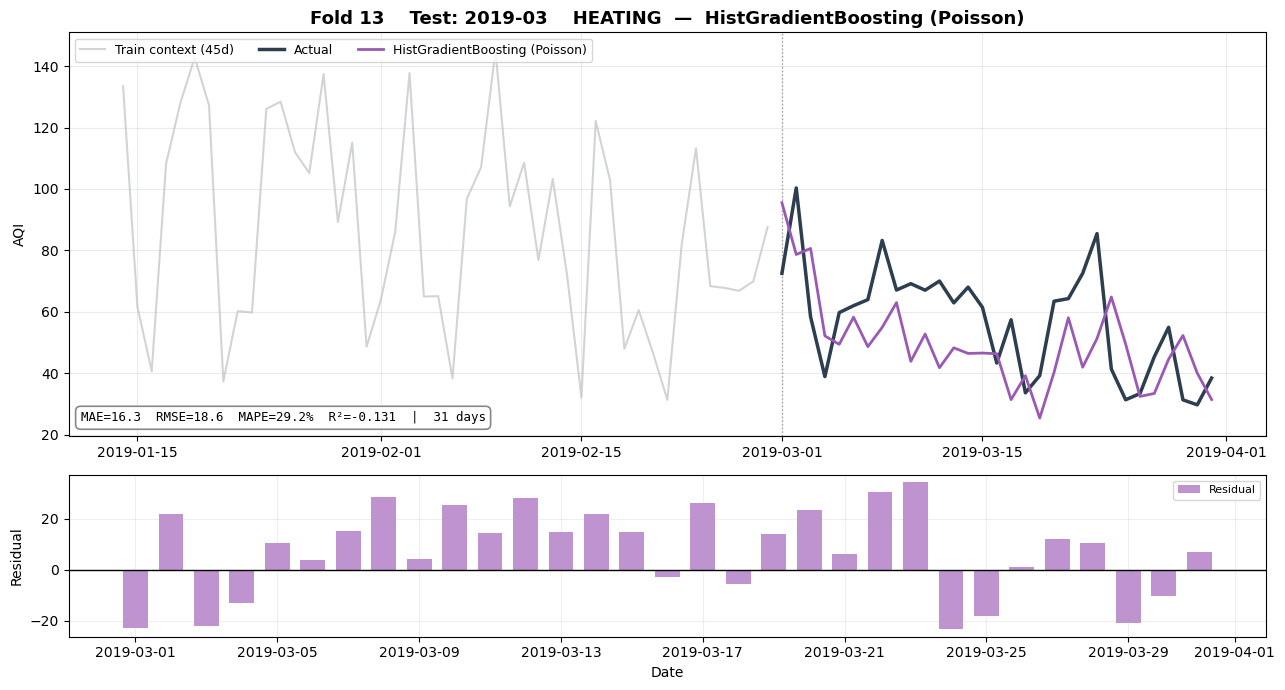

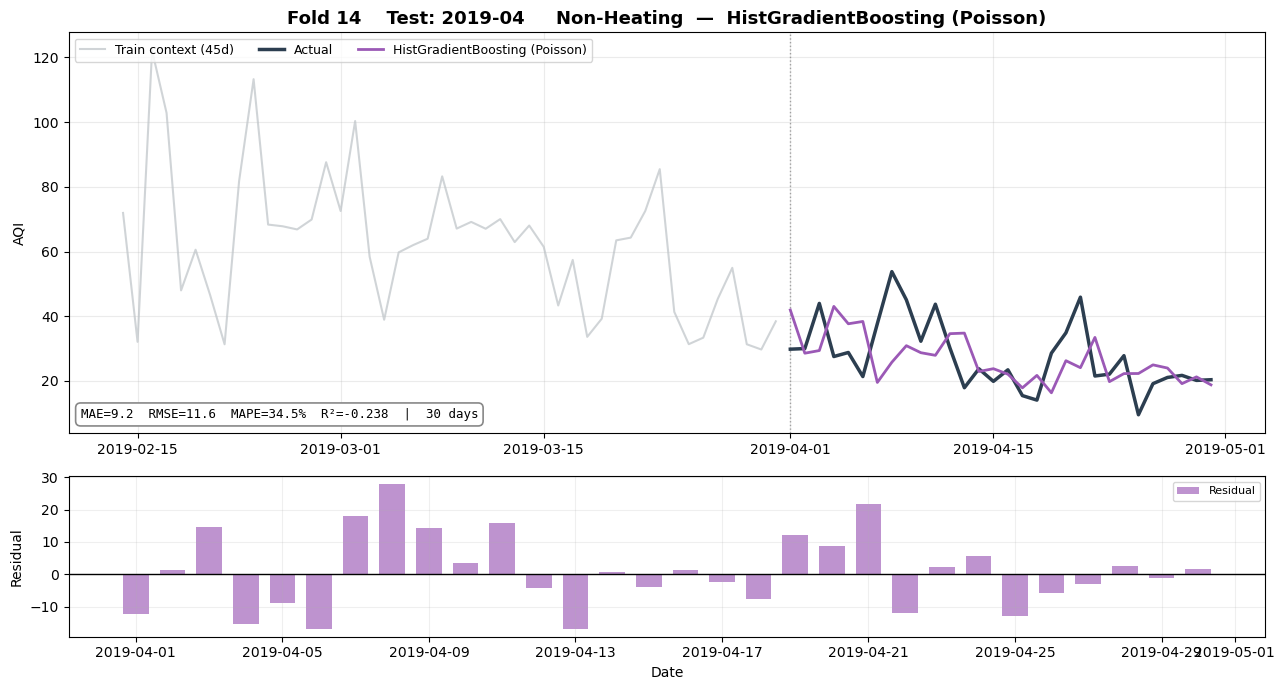

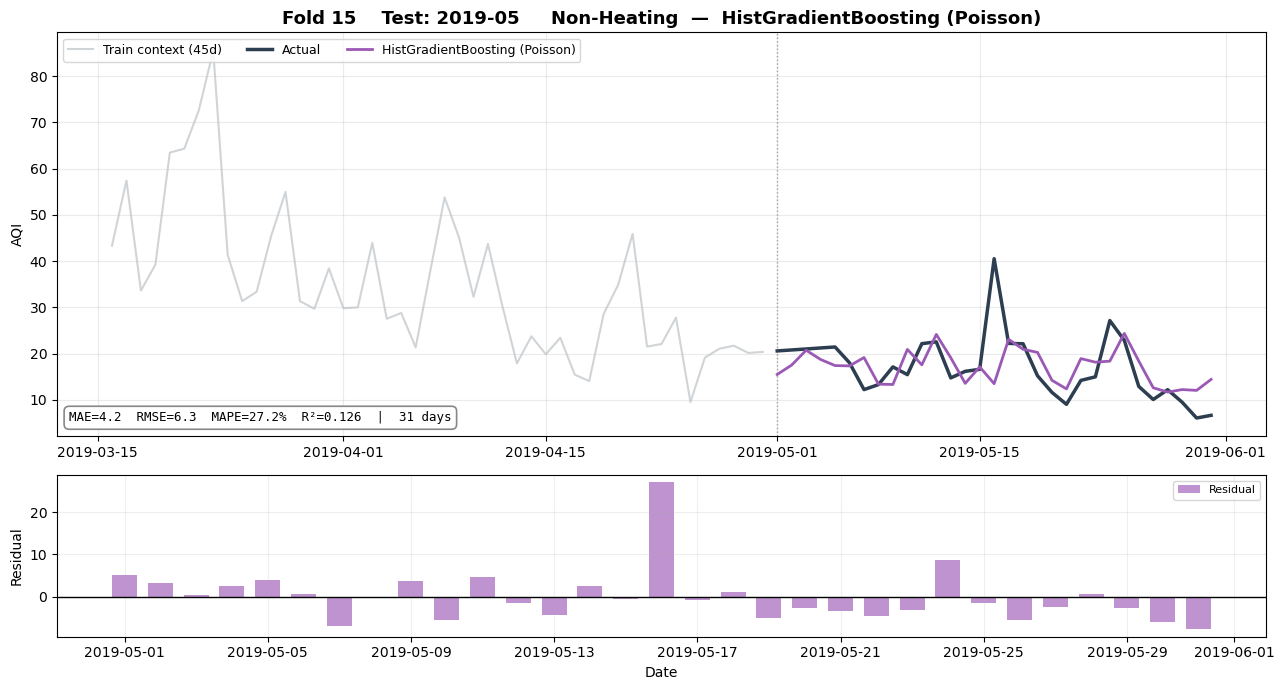

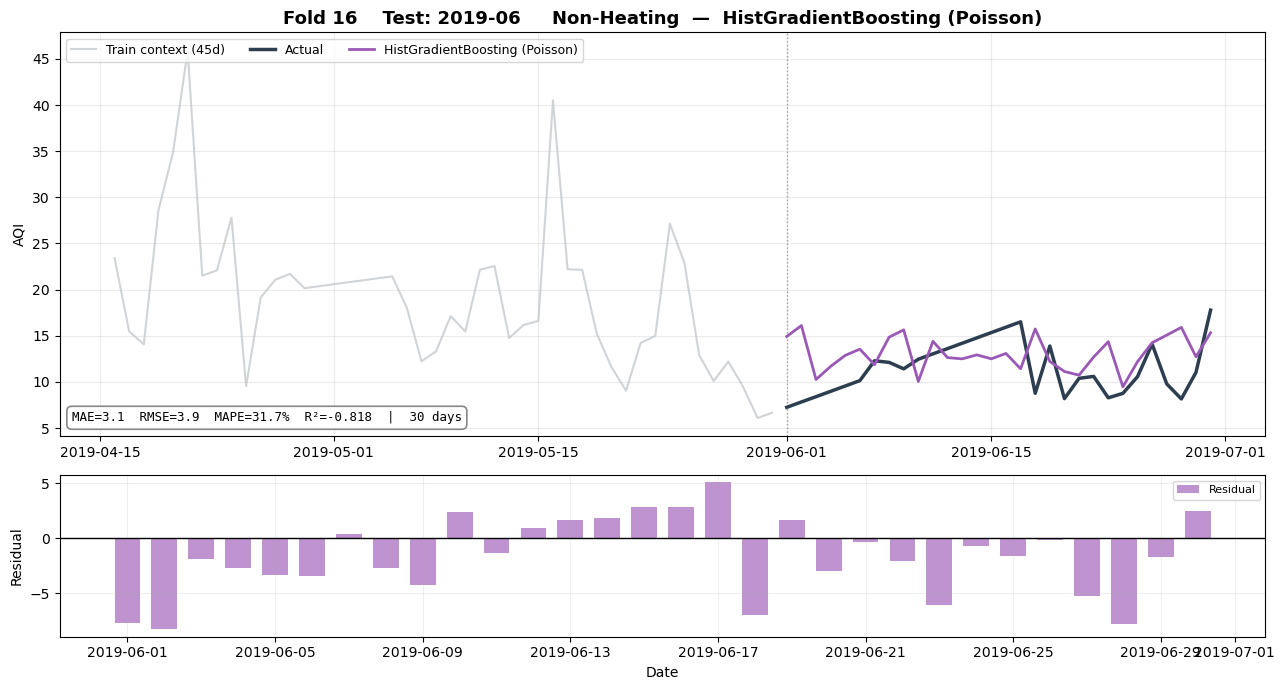

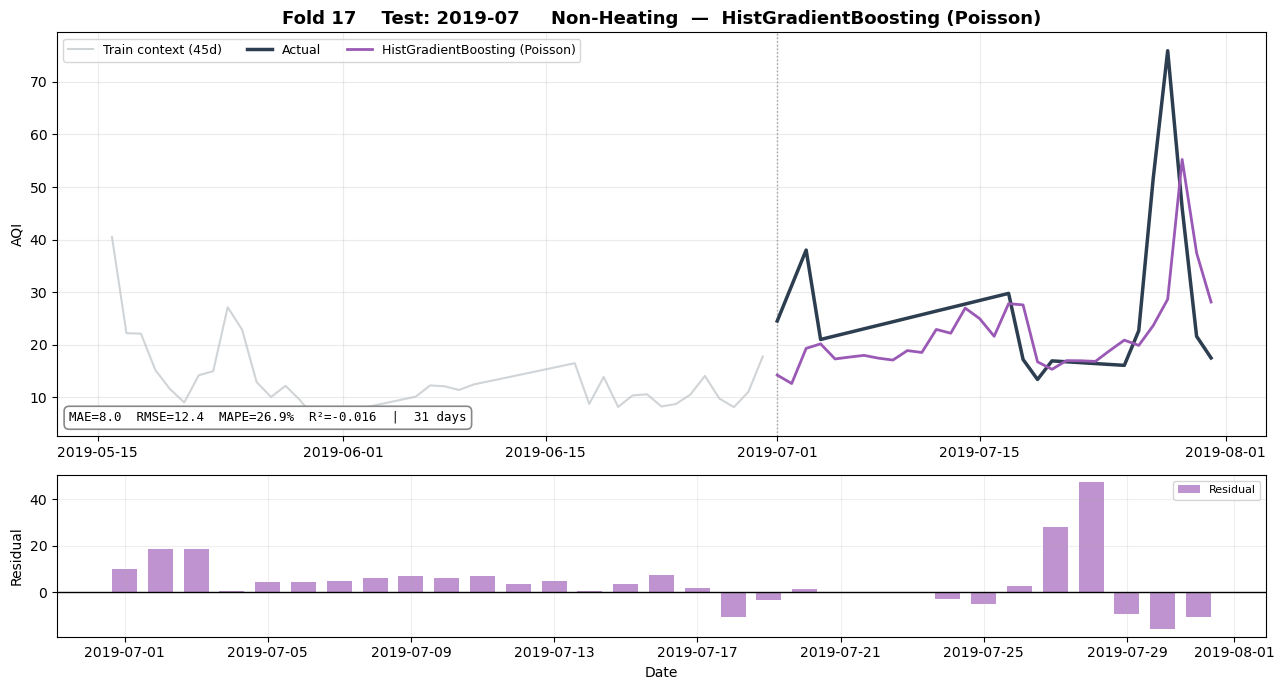

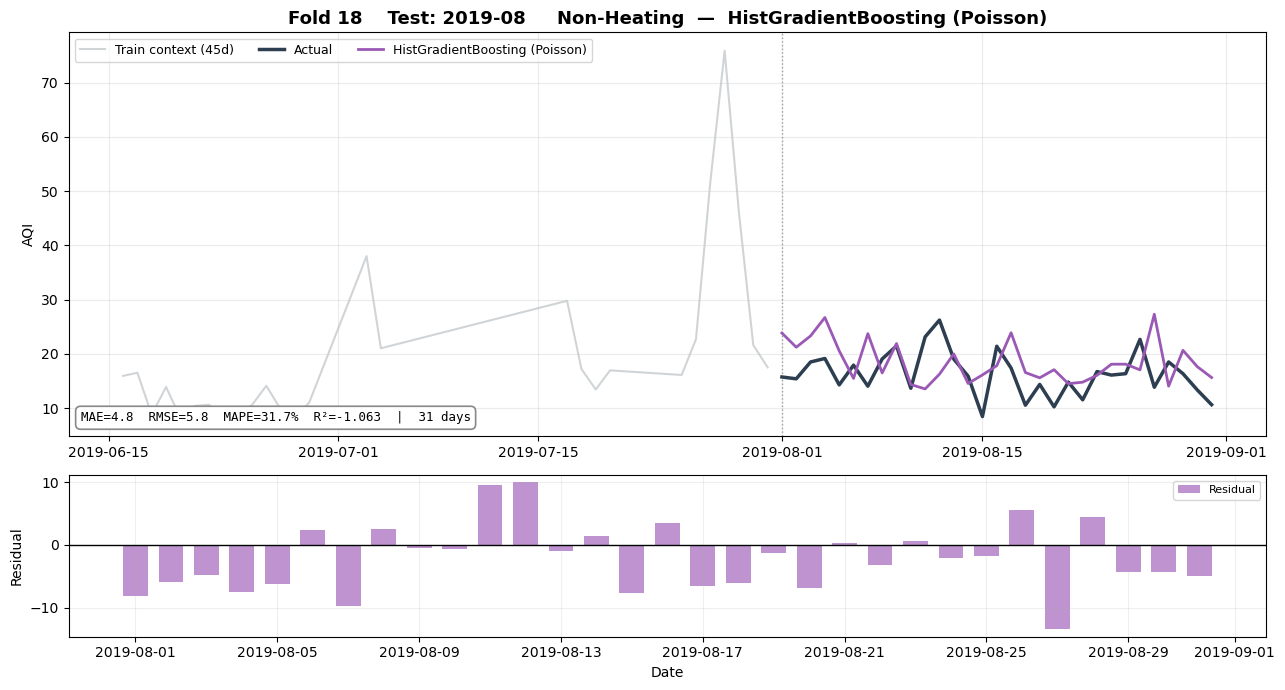

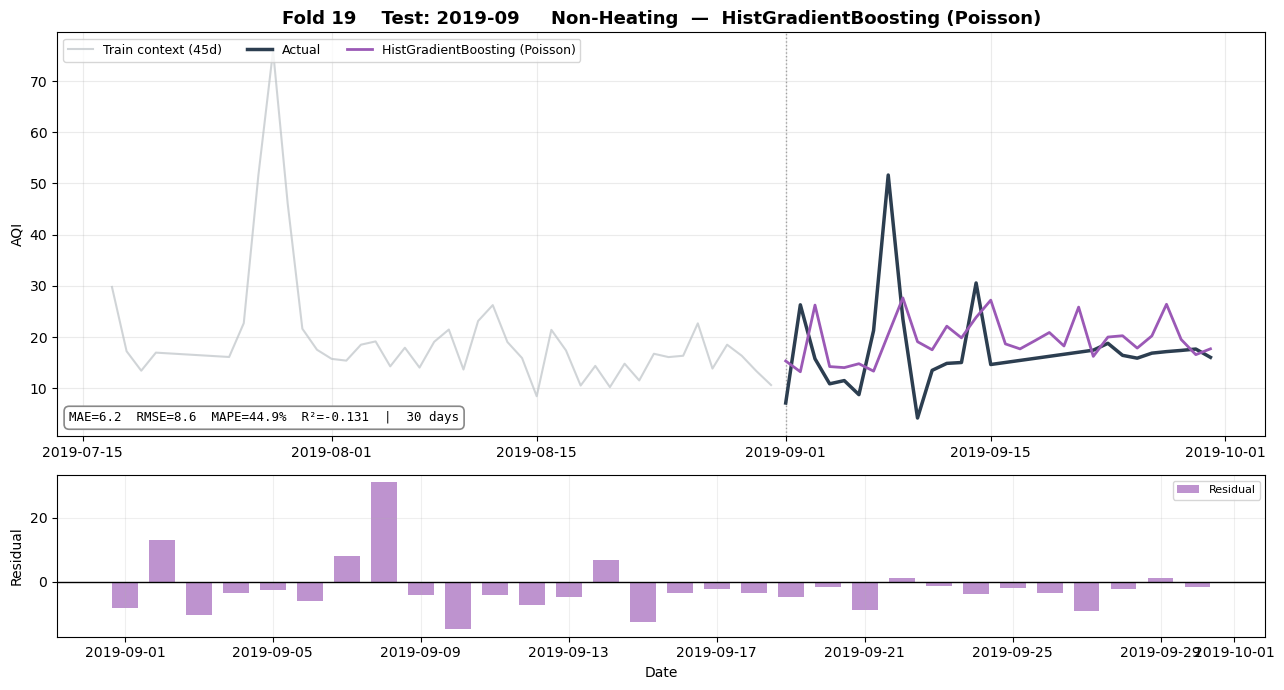

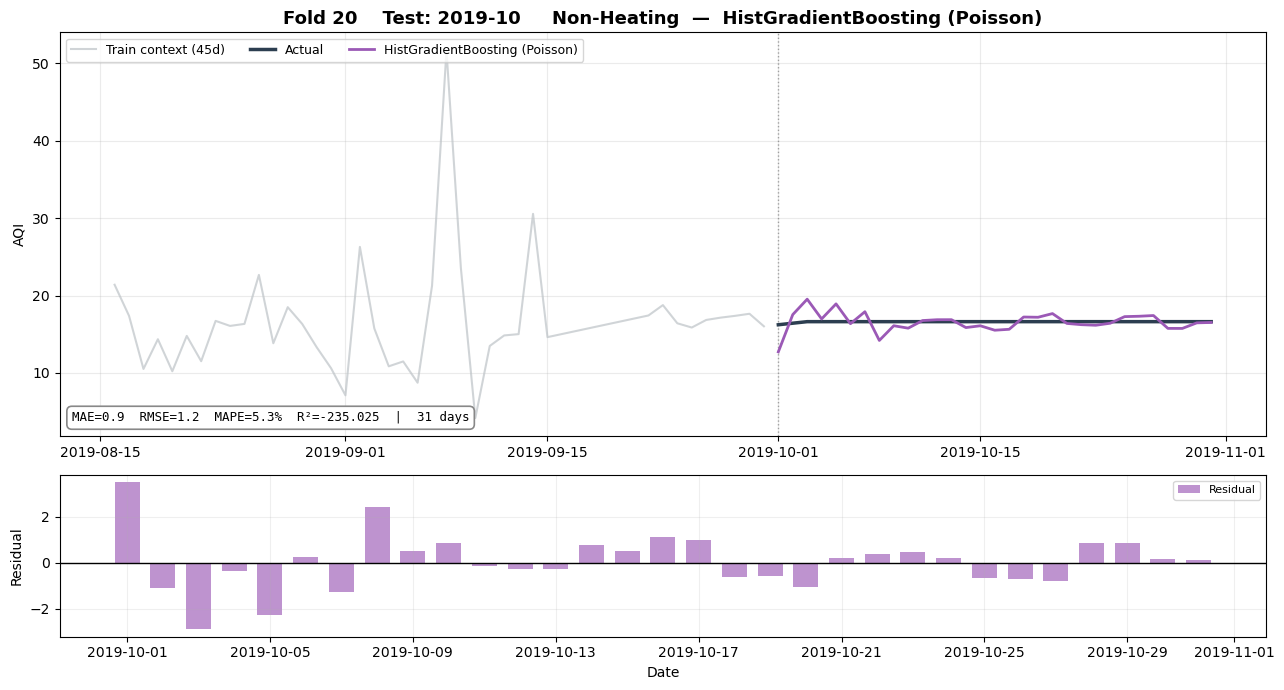

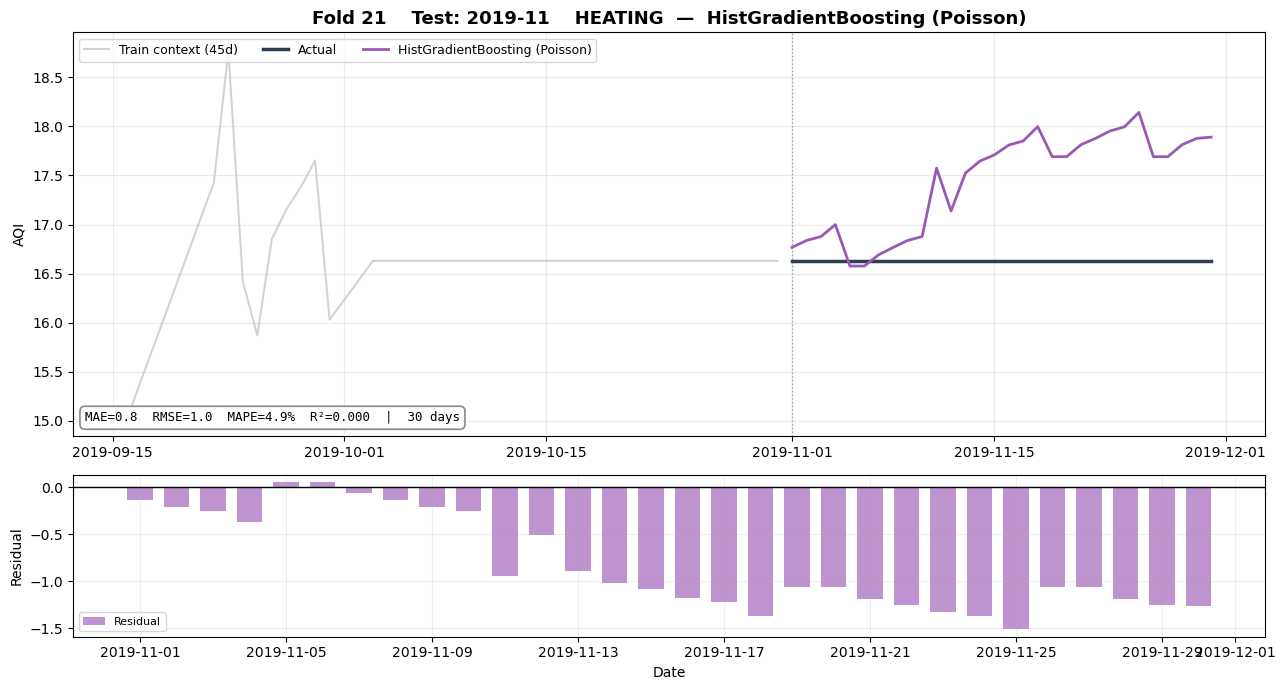

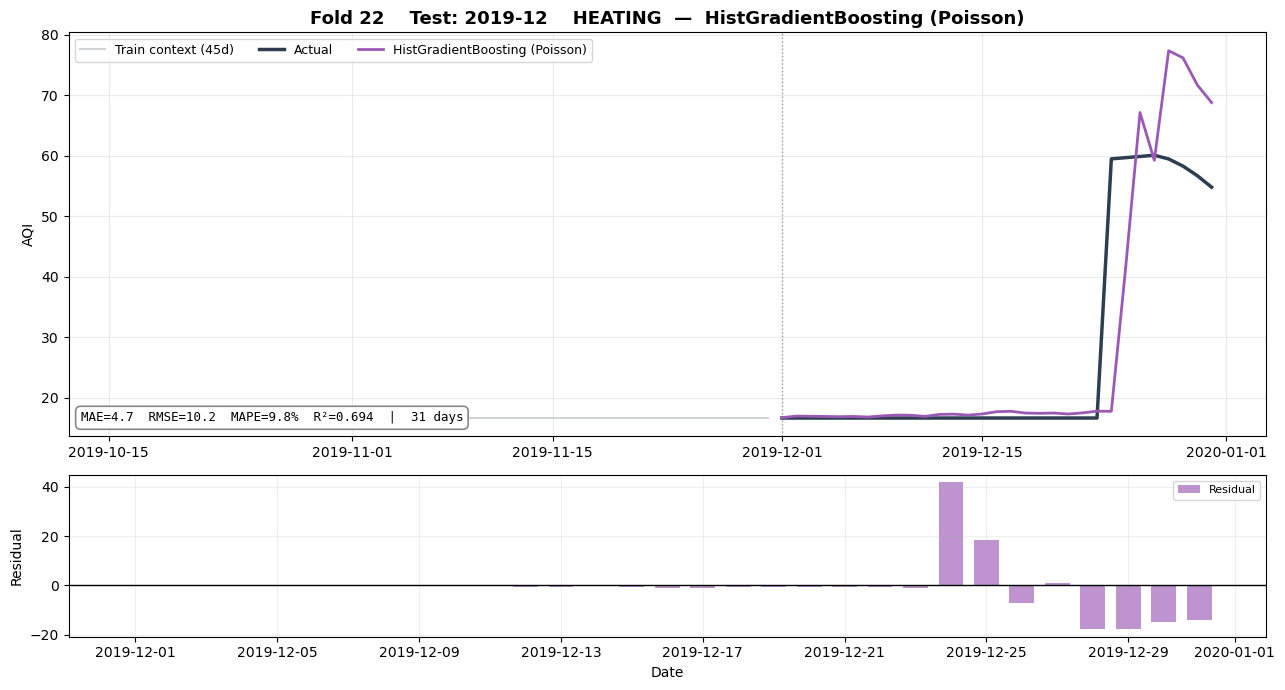

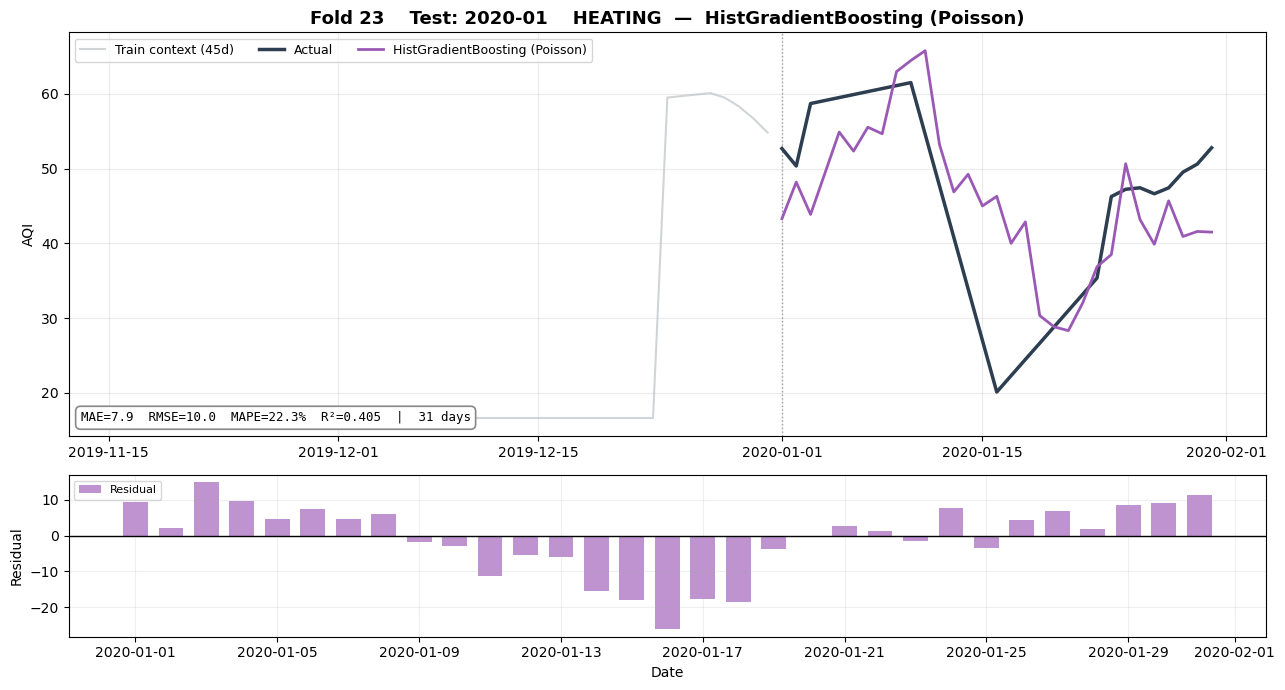

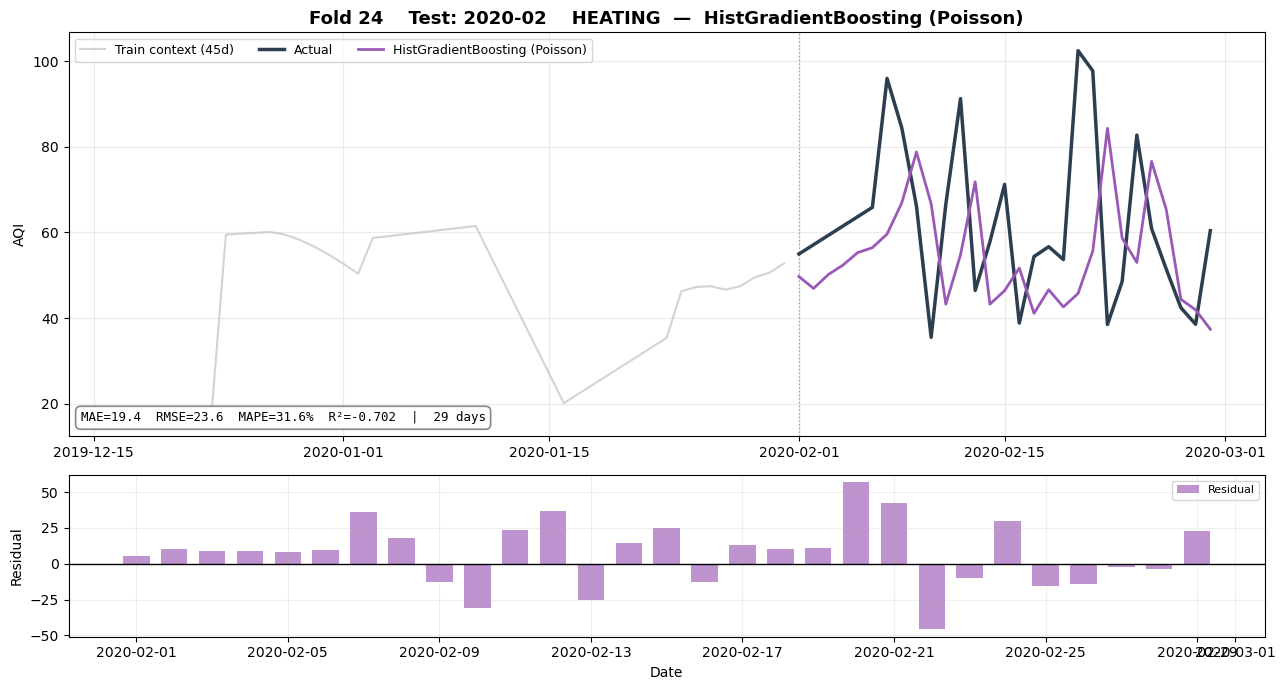

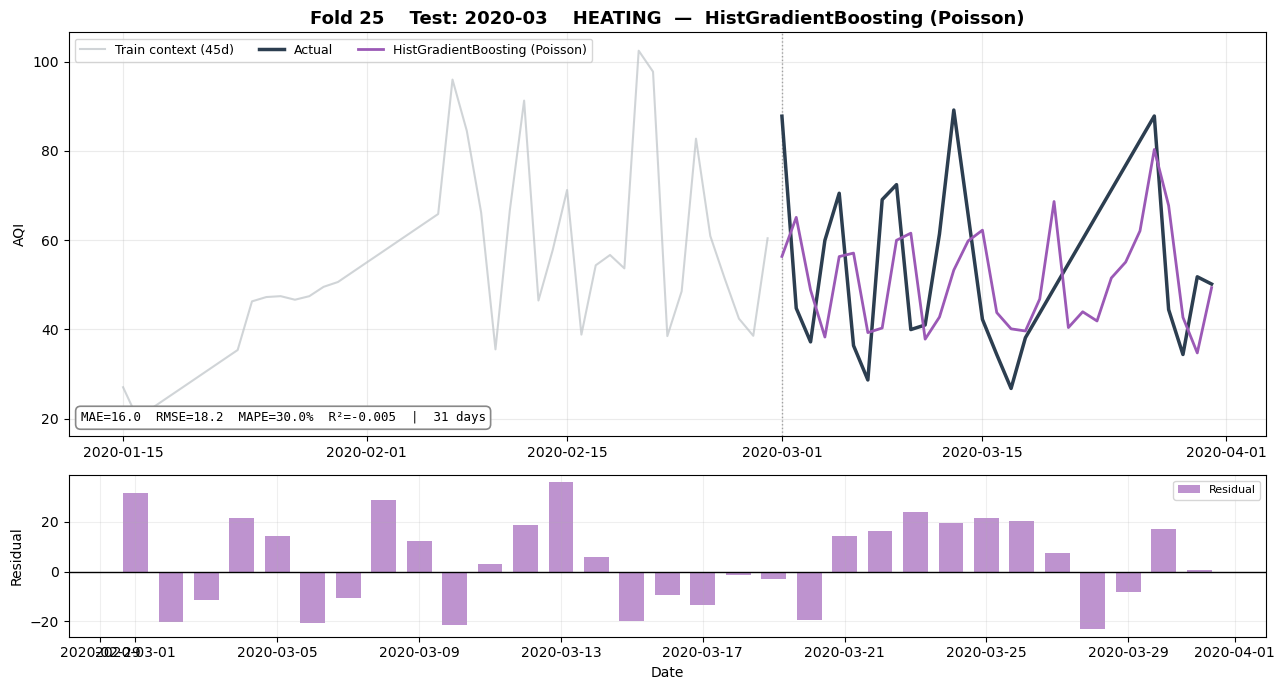

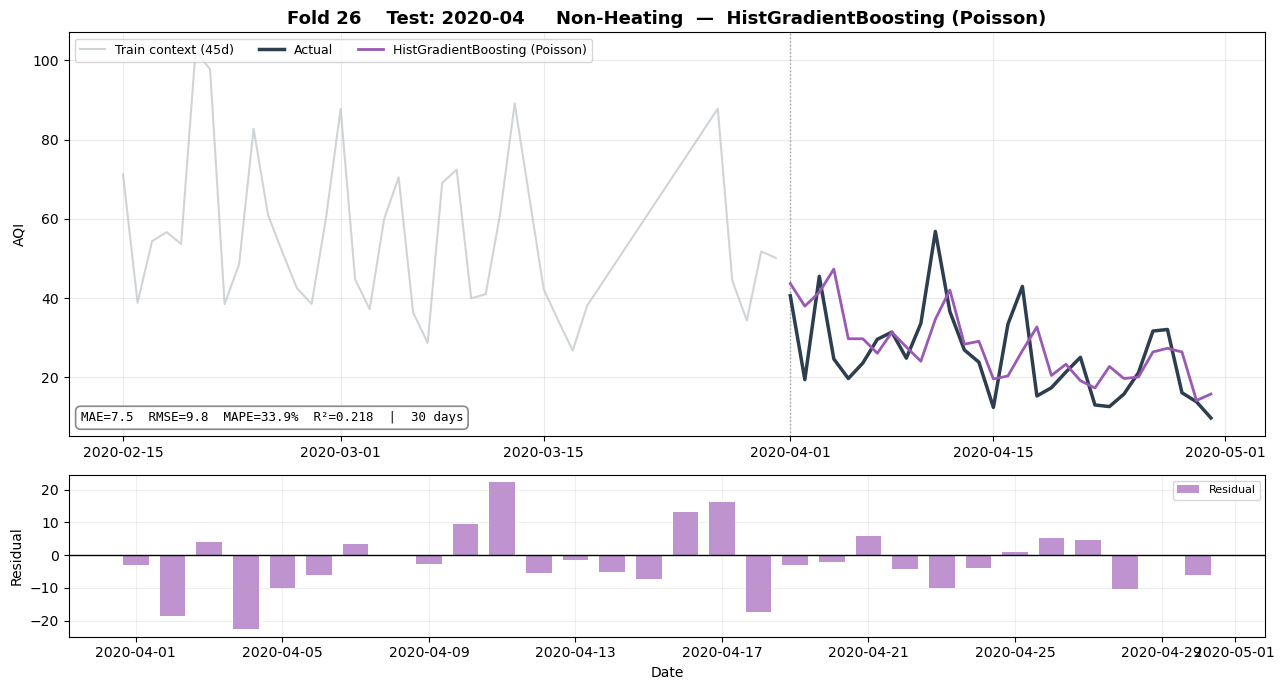

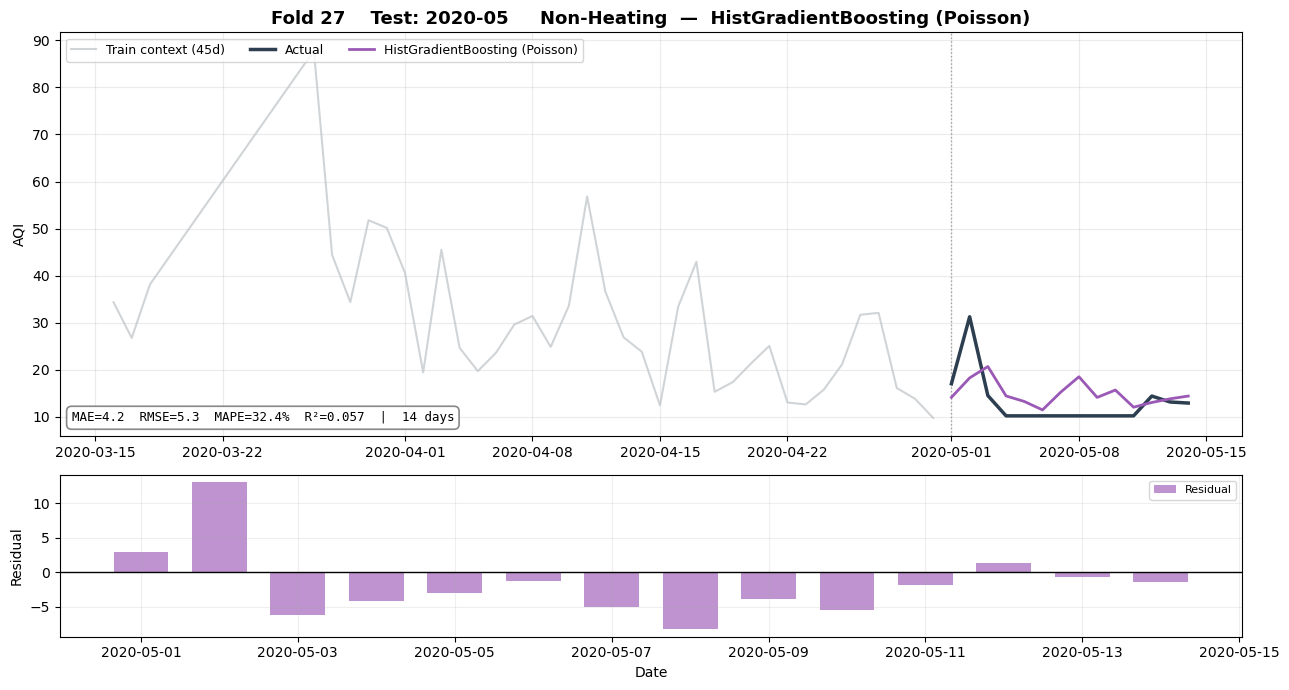

In [11]:
# Show first 3 folds in detail
for fp in fold_preds:
    fig, axes = plt.subplots(2, 1, figsize=(13, 7), sharex=False,
                              gridspec_kw={'height_ratios': [2.5, 1]})

    ax = axes[0]
    tr_dates = pd.to_datetime(fp['tr_dates'])
    ctx = tr_dates >= tr_dates[-1] - pd.Timedelta(days=45)
    ax.plot(tr_dates[ctx], fp['y_train'][ctx],
            color='#BDC3C7', lw=1.5, alpha=0.7, label='Train context (45d)')

    te_dates = pd.to_datetime(fp['dates'])
    ax.plot(te_dates, fp['y_true'],
            color='#2C3E50', lw=2.5, label='Actual', zorder=5)
    ax.plot(te_dates, fp['pred'],
            color=MODEL_COLOR, lw=2, label=MODEL_NAME, zorder=6)

    ax.axvline(te_dates[0], color='grey', lw=1, ls=':', alpha=0.7)
    ax.set_ylabel('AQI')

    heating_tag = 'HEATING' if fp['is_heating_test'] else ' Non-Heating'
    ax.set_title(f'Fold {fp["fold"]}    Test: {fp["test_month"]}    {heating_tag}  —  {MODEL_NAME}',
                 fontsize=13, fontweight='bold')
    ax.legend(fontsize=9, ncol=3, loc='upper left')
    ax.grid(alpha=0.25)

    fr = [r for r in fold_results if r['fold'] == fp['fold']][0]
    txt = (f"MAE={fr['MAE']:.1f}  RMSE={fr['RMSE']:.1f}  "
           f"MAPE={fr['MAPE(%)']:.1f}%  R²={fr['R2']:.3f}  |  {fr['n_test_days']} days")
    ax.annotate(txt, xy=(0.01, 0.03), xycoords='axes fraction',
                fontsize=9, va='bottom', family='monospace',
                bbox=dict(boxstyle='round,pad=0.4', fc='white', ec='#888', lw=1.2))

    ax2 = axes[1]
    ax2.bar(te_dates, fp['y_true'] - fp['pred'],
            color=MODEL_COLOR, alpha=0.65, label='Residual', width=0.7)
    ax2.axhline(0, color='black', lw=1)
    ax2.set_ylabel('Residual'); ax2.set_xlabel('Date')
    ax2.legend(fontsize=8); ax2.grid(alpha=0.2)

    plt.tight_layout()
    plt.show()

## 9. Combined Overview — All Folds

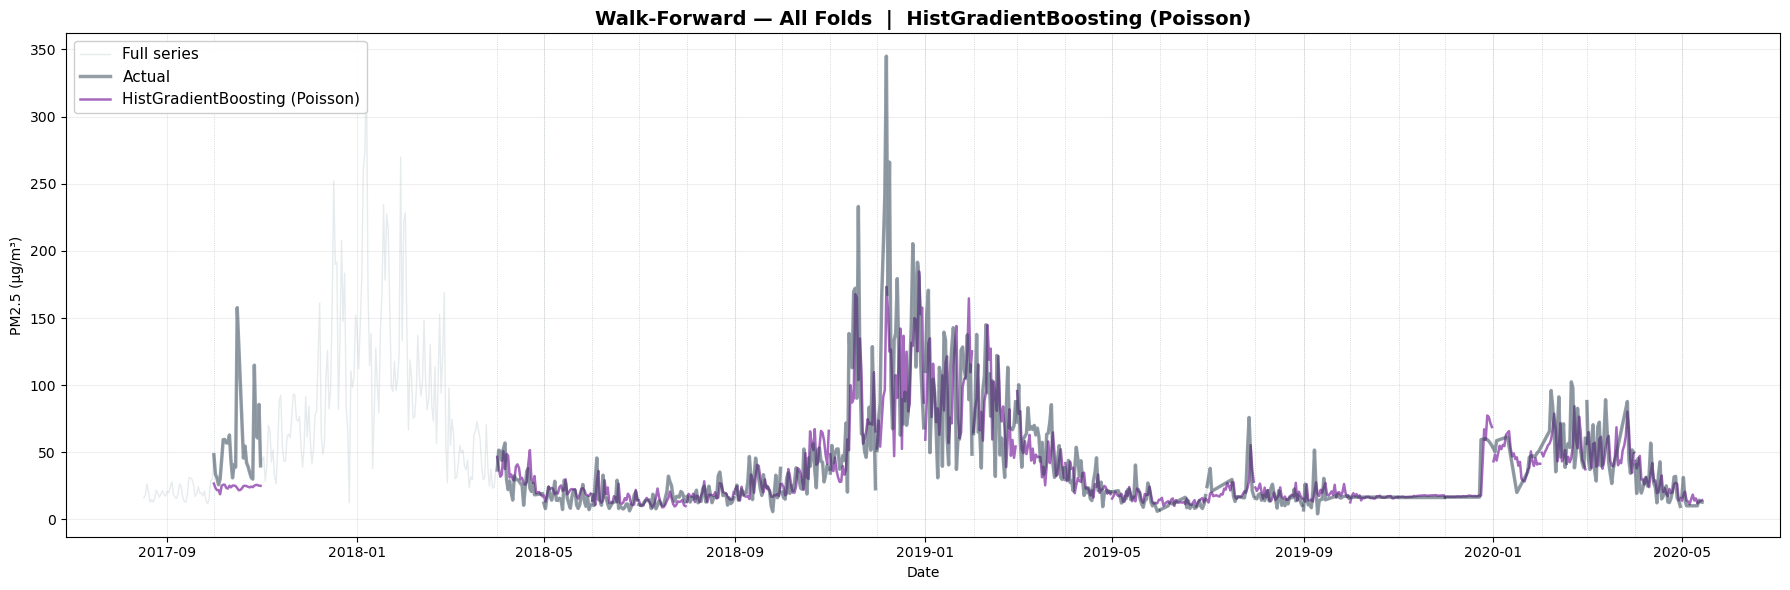

In [12]:
fig, ax = plt.subplots(figsize=(18, 6))
ax.plot(feat_df['ds'], feat_df['y'], color='#CFD8DC', lw=1, alpha=0.5,
        label='Full series', zorder=1)

first = True
for fp in fold_preds:
    te_dates = pd.to_datetime(fp['dates'])
    ax.plot(te_dates, fp['y_true'],  color='#2C3E50', lw=2.5, zorder=7,alpha=0.5,
            **(dict(label='Actual') if first else {}))
    ax.plot(te_dates, fp['pred'],    color=MODEL_COLOR, lw=1.8, alpha=0.9, zorder=6,
            **(dict(label=MODEL_NAME) if first else {}))
    ax.axvline(te_dates[0], color='#90A4AE', lw=0.6, ls=':', alpha=0.5)
    first = False

ax.set_title(f'Walk-Forward — All Folds  |  {MODEL_NAME}', fontsize=14, fontweight='bold')
ax.set_xlabel('Date'); ax.set_ylabel('PM2.5 (µg/m³)')
ax.legend(fontsize=11, loc='upper left', framealpha=0.95)
ax.grid(alpha=0.2)
plt.tight_layout()
plt.show()

## 10. Metrics Summary & Performance by Season 

In [13]:
results_df = pd.DataFrame(fold_results)

print(f'  {MODEL_NAME} — Walk-Forward Results')

print(results_df[['fold','test_month','n_train_days','n_test_days','is_heating_test','MAE','RMSE','MAPE(%)','R2']].to_string(index=False))

print(f'\nOverall Averages:  MAE={results_df["MAE"].mean():.2f}  '
      f'RMSE={results_df["RMSE"].mean():.2f}  '
      f'MAPE={results_df["MAPE(%)"].mean():.1f}%  '
      f'R²={results_df["R2"].mean():.3f}')

# ─── PERFORMANCE BY HEATING/NON-HEATING SEASON ────────────────────────────

print('Performance Summary by Season:')


for season_type, is_heating in [('Heating Season (Nov-Mar)', True),
                                  ('Non-Heating (Apr-Oct)', False)]:
    subset = results_df[results_df['is_heating_test'] == is_heating]
    if len(subset) > 0:
        print(f'\n{season_type}: {len(subset)} test months')
        print(f'  MAE:  {subset["MAE"].mean():.2f} ± {subset["MAE"].std():.2f}')
        print(f'  RMSE: {subset["RMSE"].mean():.2f} ± {subset["RMSE"].std():.2f}')
        print(f'  MAPE: {subset["MAPE(%)"].mean():.1f}% ± {subset["MAPE(%)"].std():.1f}%')
        print(f'  R²:   {subset["R2"].mean():.3f} ± {subset["R2"].std():.3f}')



  HistGradientBoosting (Poisson) — Walk-Forward Results
 fold test_month  n_train_days  n_test_days  is_heating_test       MAE      RMSE   MAPE(%)          R2
    1    2017-10            45           31            False 32.901284 45.163302 48.429557   -1.149722
    2    2018-04           227           30            False  9.324950 12.038371 37.642022   -0.032482
    3    2018-05           257           31            False  6.148645  7.132384 51.918380   -0.317635
    4    2018-06           288           30            False  7.287815  9.778329 52.799076   -0.300732
    5    2018-07           318           31            False  4.491252  5.844550 28.749413   -0.148099
    6    2018-08           349           31            False  3.798418  4.919019 21.626184    0.270078
    7    2018-09           380           30            False  6.698348  9.439514 30.693772    0.007981
    8    2018-10           410           31            False 12.430398 15.611813 38.824206   -0.784706
    9    2018-11 

## 11. Metrics per Fold

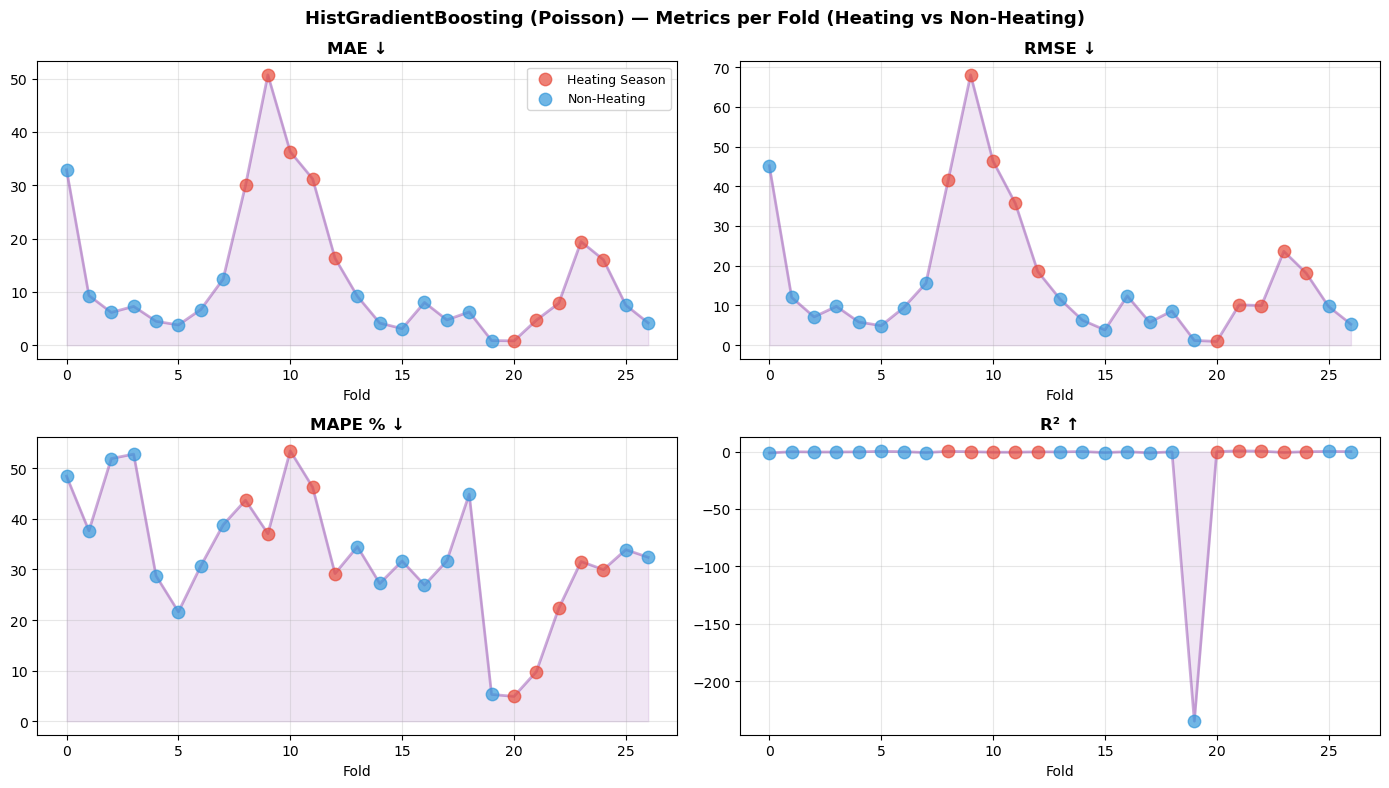

In [14]:
fig, axes = plt.subplots(2, 2, figsize=(14, 8))
cfg = [('MAE','MAE ↓'),('RMSE','RMSE ↓'),('MAPE(%)','MAPE % ↓'),('R2','R² ↑')]

for ax, (col, title) in zip(axes.flatten(), cfg):
    # Color points by heating season
    heating = results_df['is_heating_test']
    ax.scatter(results_df[heating].index, results_df[heating][col],
              color='#E74C3C', s=80, alpha=0.7, label='Heating Season', zorder=3)
    ax.scatter(results_df[~heating].index, results_df[~heating][col],
              color='#3498DB', s=80, alpha=0.7, label='Non-Heating', zorder=3)

    ax.plot(results_df.index, results_df[col],
            color=MODEL_COLOR, lw=2, alpha=0.5, zorder=2)
    ax.fill_between(results_df.index, results_df[col],
                    alpha=0.15, color=MODEL_COLOR, zorder=1)
    ax.set_title(title, fontweight='bold'); ax.set_xlabel('Fold')
    ax.set_xticks(range(0, len(results_df), max(1, len(results_df)//5)))
    ax.grid(alpha=0.3)
    if ax == axes[0, 0]:
        ax.legend(fontsize=9)

fig.suptitle(f'{MODEL_NAME} — Metrics per Fold (Heating vs Non-Heating)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## 12. Feature Importance

In [15]:
# ── Feature importance ─────────────────────────────────────────────────
if lgb_imps:
    imp_df   = pd.concat(lgb_imps, axis=1).fillna(0)
    imp_mean = imp_df.mean(axis=1).sort_values(ascending=False)
    imp_std  = imp_df.std(axis=1).fillna(0)

    bar_colors = ['#E74C3C' if 'lag' in f else
                  '#9B59B6' if 'ewm' in f else
                  '#3498DB' if 'roll' in f else '#95A5A6'
                  for f in imp_mean.index]

    fig, ax = plt.subplots(figsize=(9, 6))
    ax.barh(imp_mean.index[::-1], imp_mean.values[::-1],
            xerr=imp_std.loc[imp_mean.index].values[::-1],
            color=bar_colors[::-1], edgecolor='black', linewidth=0.6,
            capsize=3, alpha=0.88)
    ax.set_title(f'{MODEL_NAME} — Feature Importance\n(mean ± std across folds)',
                 fontsize=13, fontweight='bold')
    ax.set_xlabel('Mean Gain'); ax.grid(axis='x', alpha=0.3)
    patches = [mpatches.Patch(color='#E74C3C', label='Lags'),
               mpatches.Patch(color='#9B59B6', label='EWM'),
               mpatches.Patch(color='#3498DB', label='Rolling'),
               mpatches.Patch(color='#95A5A6', label='Calendar')]
    ax.legend(handles=patches, fontsize=9)
    plt.tight_layout()
    plt.show()

## 13. Export Results (Optional)

In [16]:
'''# ── Save results to CSV ────────────────────────────────────────────────────
# Uncomment below to save:

# results_df.to_csv('walk_forward_results.csv', index=False)
# rows = []
# for fp in fold_preds:
#     for d, yt, yp in zip(fp['dates'], fp['y_true'], fp['pred']):
#         rows.append({'fold': fp['fold'], 'test_month': fp['test_month'],
#                      'is_heating': fp['is_heating_test'],
#                      'date': d, 'y_true': yt, 'pred': yp})
# pd.DataFrame(rows).to_csv('walk_forward_predictions.csv', index=False)
# print('✓ walk_forward_results.csv  |  walk_forward_predictions.csv')

print('✓ Results available in results_df DataFrame')
print(f'\nShape: {results_df.shape}')
print(f'Columns: {list(results_df.columns)}')'''

"# ── Save results to CSV ────────────────────────────────────────────────────\n# Uncomment below to save:\n\n# results_df.to_csv('walk_forward_results.csv', index=False)\n# rows = []\n# for fp in fold_preds:\n#     for d, yt, yp in zip(fp['dates'], fp['y_true'], fp['pred']):\n#         rows.append({'fold': fp['fold'], 'test_month': fp['test_month'],\n#                      'is_heating': fp['is_heating_test'],\n#                      'date': d, 'y_true': yt, 'pred': yp})\n# pd.DataFrame(rows).to_csv('walk_forward_predictions.csv', index=False)\n# print('✓ walk_forward_results.csv  |  walk_forward_predictions.csv')\n\nprint('✓ Results available in results_df DataFrame')\nprint(f'\nShape: {results_df.shape}')\nprint(f'Columns: {list(results_df.columns)}')"